In [1]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc, mcscf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class RHFSpectralMoments:

    def __init__(self, mf):

        self.mf = mf
        self.mol = mf.mol

        self.nmo = mf.mo_coeff.shape[1]
        self.nelec = self.mol.nelectron
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.constant_energy = self.mol.energy_nuc()

        self.one_mo, self.two_mo = self.build_mo_integrals()
        self.qubit_hamiltonian = self.build_qubit_hamiltonian()
        self.Hmat = qml.matrix(self.qubit_hamiltonian, wire_order=self.wires)

        self.a, self.adag = self.build_fermionic_operators()

        self.device =  qml.device("default.qubit", wires=self.n_spin_orbitals)

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        return observable(h1, h2, mapping="jordan_wigner")

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy + self.constant_energy
            energy_history.append(total_energy)

            if step % 10 == 0:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy + self.constant_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0 + self.constant_energy,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.constant_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

In [ ]:
mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4', 
    basis = 'sto-6g', # minimal basis set
    spin = 0 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

In [ ]:
engine = RHFSpectralMoments(mf)

pyscf_outputs = engine.pyscf_comparisons()

vqe_outputs = engine.run_vqe(
    max_steps=100,
    stepsize=0.1,
) 

moments = engine.compute_moments(
    theta=vqe_outputs["vqe_params"],
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = engine.galitskii_migdal_energy(hole_moments)


print("")
print('Energy Comparsions')
print("-------------------")
print(f"PySCF Hartree-Fock energy: {pyscf_outputs['hf_energy']:.10f}")
print(f"PySCF FCI energy:        {pyscf_outputs['fci_energy']:.10f}")
if pyscf_outputs["ccsd_energy"] is not None:
    print(f"PySCF CCSD energy:       {pyscf_outputs['ccsd_energy']:.10f}")
print(f"VQE total energy:       {vqe_outputs['vqe_total_energy']:.10f}")
print(f"Galitskii-Migdal energy from moments: {gm['total']:.10f}")

omega_grid = np.linspace(-5, 5, 1000)

gf_data = engine.greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

### CASSCF

In [1]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc, mcscf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class CASSpectralMoments:

    def __init__(
        self,
        mf,
        ncas,
        nelecas,
        mo_coeff=None,
    ):

        self.mf = mf
        self.mol = mf.mol

        self.ncas = ncas
        self.nelecas = nelecas

        # CASCI object
        self.cas = mcscf.CASCI(
            mf,
            ncas,
            nelecas,
        )

        if mo_coeff is None:
            mo_coeff = mf.mo_coeff

        self.mo_coeff = mo_coeff

        # Active-space Hamiltonian
        self.h1eff, self.ecore = self.cas.get_h1eff(self.mo_coeff)

        eri_cas = self.cas.get_h2eff(self.mo_coeff)
        eri_cas = ao2mo.restore(1, eri_cas, ncas)

        self.one_mo = self.h1eff
        self.two_mo = np.swapaxes(eri_cas, 1, 3)

        # Active-space dimensions
        self.nmo = ncas
        self.nelec = nelecas

        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.constant_energy = self.ecore

        # Build qubit Hamiltonian
        self.qubit_hamiltonian = (
            self.build_qubit_hamiltonian()
        )

        self.Hmat = qml.matrix(
            self.qubit_hamiltonian,
            wire_order=self.wires,
        )

        self.a, self.adag = (
            self.build_fermionic_operators()
        )

        self.device = qml.device(
            "default.qubit",
            wires=self.n_spin_orbitals,
        )

    def build_mo_integrals(self):

        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):

        # Mo basis
        
        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        H = observable(
            h1,
            h2,
            mapping="jordan_wigner",
        )

        # add frozen-core/nuclear constant
        H += self.ecore * qml.Identity(0)

        return H

    def pyscf_comparisons(self):

        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):

        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None):

        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy
            energy_history.append(total_energy)

            if step % 10 == 0:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def expval_on_vqe_state(self, theta, observable):
        
        dev = self.device

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def circuit(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(observable)

        return circuit(theta)

    def compute_moments(self, theta, nmom=1):
        """
        PennyLane equivalent of your Qiskit DirectMethod moment calculation.

        Computes moments as expectation values:

            <Psi(theta)| O_moment |Psi(theta)>

        rather than by direct statevector contraction.
        """

        E0 = self.expval_on_vqe_state(
            theta,
            self.qubit_hamiltonian,
        )

        H_particle = self.Hmat - E0 * np.eye(2**self.n_spin_orbitals)
        H_hole = E0 * np.eye(2**self.n_spin_orbitals) - self.Hmat

        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):

            Hh_n = np.linalg.matrix_power(H_hole, n)
            Hp_n = np.linalg.matrix_power(H_particle, n)

            for i in range(self.nmo):
                for j in range(self.nmo):

                    ia, ib = 2*i, 2*i + 1
                    ja, jb = 2*j, 2*j + 1

                    # Hole moment operator:
                    # a_i^dag (E0 - H)^n a_j
                    O_h = (
                        self.adag[ia] @ Hh_n @ self.a[ja]
                        + self.adag[ib] @ Hh_n @ self.a[jb]
                    )

                    # Particle moment operator:
                    # a_i (H - E0)^n a_j^dag
                    O_p = (
                        self.a[ia] @ Hp_n @ self.adag[ja]
                        + self.a[ib] @ Hp_n @ self.adag[jb]
                    )

                    # Make Hermitian for PennyLane measurement
                    O_h = 0.5 * (O_h + O_h.conj().T)
                    O_p = 0.5 * (O_p + O_p.conj().T)

                    obs_h = qml.Hermitian(O_h, wires=self.wires)
                    obs_p = qml.Hermitian(O_p, wires=self.wires)

                    hole_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_h)
                    particle_moments[n, i, j] = self.expval_on_vqe_state(theta, obs_p)

        return {
            "E0_electronic": E0,
            "E0_total": E0,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.constant_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

In [7]:
ncas = 3
nelecas = 4

def build_silanol_active_space(
    basis="sto-3g",
    ncas=ncas,
    nelecas=nelecas,
):
    """
    H3SiOH toy model.

    Aerospace/coating interpretation:
    - small hydroxylated silicon/silica fragment
    - relevant as a toy model for water/hydrogen attack on Si-based ceramic/EBC systems

    ncas=3 gives 6 qubits.
    nelecas=4 gives CAS(4e,3o).
    """

    mol = gto.Mole()
    mol.atom = """
    Si  0.000000   0.000000   0.000000
    O   0.000000   0.000000   1.640000
    H   0.000000   0.000000   2.600000
    H   1.400000   0.000000  -0.500000
    H  -0.700000   1.212436  -0.500000
    H  -0.700000  -1.212436  -0.500000
    """

    mol.basis = basis
    mol.charge = 0
    mol.spin = 0
    mol.unit = "Angstrom"
    mol.build()

    mf = scf.RHF(mol)
    mf.kernel()

    if not mf.converged:
        raise RuntimeError("RHF did not converge")

    mc = mcscf.CASCI(mf, ncas, nelecas)

    h1eff, ecore = mc.get_h1eff()
    eri_cas = mc.get_h2eff()
    eri_cas = ao2mo.restore(1, eri_cas, ncas)

    return mol, mf, mc, h1eff, ecore, eri_cas


mol, mf, mc, h1eff, ecore, eri_cas = build_silanol_active_space()

print("Total electrons:", mol.nelectron)
print("HF energy:", mf.e_tot)
print("ecore:", ecore)
print("h1eff shape:", h1eff.shape)
print("eri_cas shape:", eri_cas.shape)
print("n qubits:", 2 * h1eff.shape[0])

np.save("silanol_h1eff.npy", h1eff)
np.save("silanol_ecore.npy", np.array(ecore))
np.save("silanol_eri_cas.npy", eri_cas)

converged SCF energy = -361.714030171318
Total electrons: 26
HF energy: -361.71403017131803
ecore: -356.88337664138663
h1eff shape: (3, 3)
eri_cas shape: (3, 3, 3, 3)
n qubits: 6


Step   0 | Total VQE energy = -361.7140301713
Step  10 | Total VQE energy = -361.7152196373
Step  20 | Total VQE energy = -361.7156746362
Step  30 | Total VQE energy = -361.7158485037
Step  40 | Total VQE energy = -361.7159149229
Step  50 | Total VQE energy = -361.7159402942
Step  60 | Total VQE energy = -361.7159499858
Step  70 | Total VQE energy = -361.7159536881
Step  80 | Total VQE energy = -361.7159551023
Step  90 | Total VQE energy = -361.7159556426

Energy Comparsions
-------------------
VQE total energy:       -361.7159558490
Galitskii-Migdal energy from moments: -361.7159558490


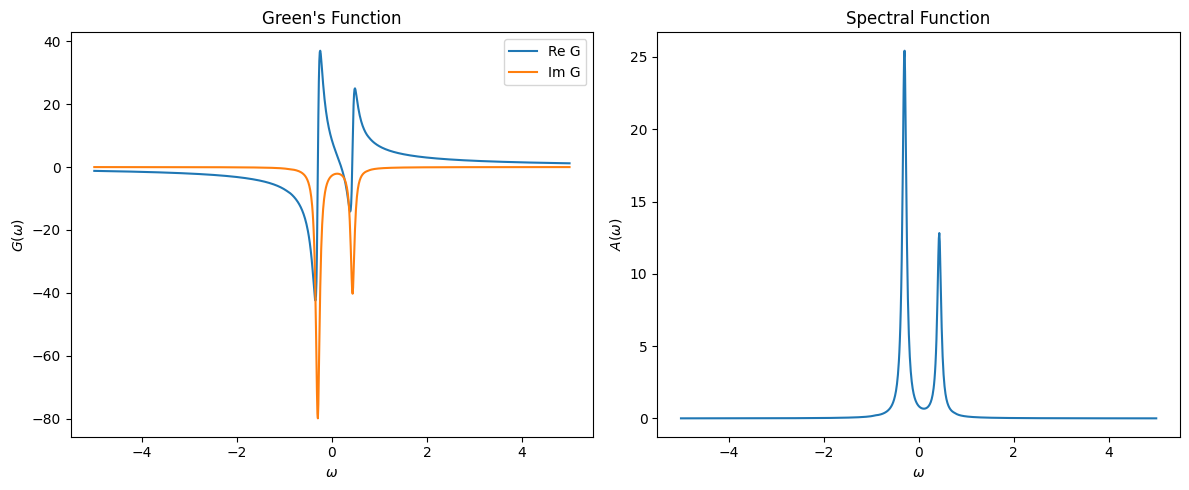

In [8]:
engine = CASSpectralMoments(
    mf=mf,
    ncas=ncas,
    nelecas=nelecas,
)

# pyscf_outputs = engine.pyscf_comparisons()

vqe_outputs = engine.run_vqe(
    max_steps=100,
    stepsize=0.1,
) 

moments = engine.compute_moments(
    theta=vqe_outputs["vqe_params"],
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = engine.galitskii_migdal_energy(hole_moments)


print("")
print('Energy Comparsions')
print("-------------------")
# print(f"PySCF Hartree-Fock energy: {pyscf_outputs['hf_energy']:.10f}")
# print(f"PySCF FCI energy:        {pyscf_outputs['fci_energy']:.10f}")
# if pyscf_outputs["ccsd_energy"] is not None:
#     print(f"PySCF CCSD energy:       {pyscf_outputs['ccsd_energy']:.10f}")
print(f"VQE total energy:       {vqe_outputs['vqe_total_energy']:.10f}")
print(f"Galitskii-Migdal energy from moments: {gm['total']:.10f}")

omega_grid = np.linspace(-5, 5, 1000)

gf_data = engine.greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()